# **Homework 01 - Machine Learning - Zoomcamp 2026**

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **Download car dataset**

In [4]:
DATA_URL =  "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df_car = pd.read_csv(DATA_URL)

df_car.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## **Question 01**

- **Problem statement: What version of Pandas did you install?**

### **Solution**

In [5]:
pd.__version__

'3.0.6'

> **Answer: 3.0.6**

## **Question 02**

- **Problem statement: How many records are in the dataset?**

### **Solution**

In [6]:
len(df_car)

10000

> **Answer: There are a total of 10000 records in the car dataset.**

## **Question 03**

- **Problem statement: How many fuel types are presented in the dataset?**

### **Solution**

In [7]:
df_car["fuel_type"].value_counts()

fuel_type
Gasoline    6913
Diesel      2053
Hybrid      1034
Name: count, dtype: int64

> **Answer: There are three types of fuel in this dataset: gasoline, diesel and hybrid types.**

## **Question 04**

- **Problem statement: How many columns in the dataset have missing values?**

### **Solution**

Check missing values registered as `NaN's`:

In [9]:
df_car.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

Check for typical problematic values filled as `'-'`:

In [26]:
missing_value_cols = []

for col in df_car.columns:
    has_dash = (
        df_car[col]
        .astype("string")
        .str.strip()
        .eq("-")
        .any()
    )

    if has_dash:
        missing_value_cols.append(col)

In [27]:
missing_value_cols

[]

> **Answer: Only two columns got missing values: `horsepower` and `acceleration`.**

## **Question 05**

- **Problem statement: What's the maximum fuel efficiency of cars from Asia?**

### **Solution**

In [31]:
df_car.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [39]:
df_car.groupby(["origin"]).agg(max_fuel=('fuel_efficiency_mpg', 'max'))

,max_fuel
origin,
Asia,41.2
Europe,39.4
USA,38.2


In [38]:
df_car.loc[df_car["origin"] == "Asia"].groupby(["origin"]).agg(max_fuel = ('fuel_efficiency_mpg','max'))

,max_fuel
origin,
Asia,41.2


> **Answer: The maximum fuel efficiency of cars from Asia is 41.2 MPG.**

## **Question 06**

- **Problem statement: Does the median value of the `horsepower` column changes after imputation? How?**

### **Solution**

In [70]:
df_car["horsepower"].isnull().sum()

np.int64(877)

In [71]:
horsepower_median = df_car["horsepower"].median()
horsepower_median

np.float64(254.0)

In [58]:
horsepower_mode = df_car["horsepower"].mode().iloc[0]

horsepower_mode

np.float64(252.0)

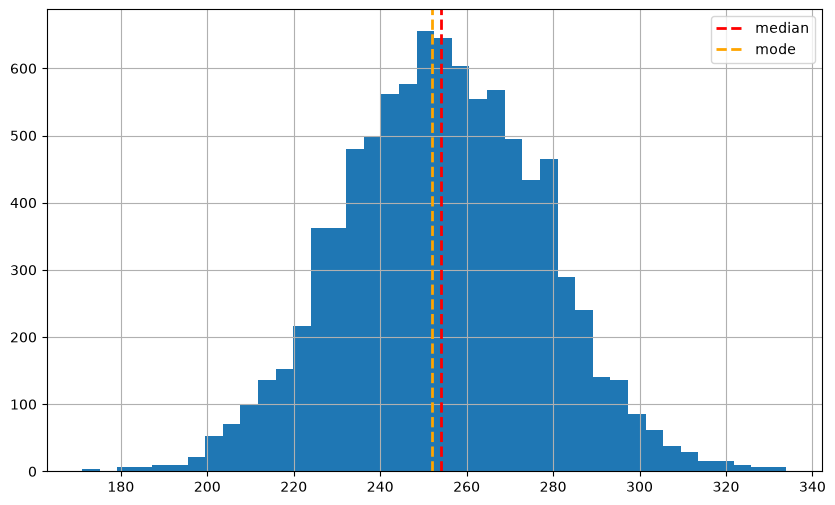

In [83]:
plt.figure(figsize=(10, 6))

df_car["horsepower"].hist(bins=40)

plt.axvline(horsepower_median, color='red', linestyle='--', linewidth=2, label=f'median')
plt.axvline(horsepower_mode, color='orange', linestyle='--', linewidth=2, label=f'mode')

plt.legend()
plt.show()

In [87]:
df_car["horsepower_filled"] = df_car["horsepower"].fillna(horsepower_mode)

df_car["horsepower_filled"].isnull().sum()

np.int64(0)

In [88]:
horsepower_filled_median = df_car["horsepower_filled"].median()
horsepower_filled_median

np.float64(252.0)

In [90]:
horsepower_filled_mode = df_car["horsepower_filled"].mode().iloc[0]
horsepower_filled_mode

np.float64(252.0)

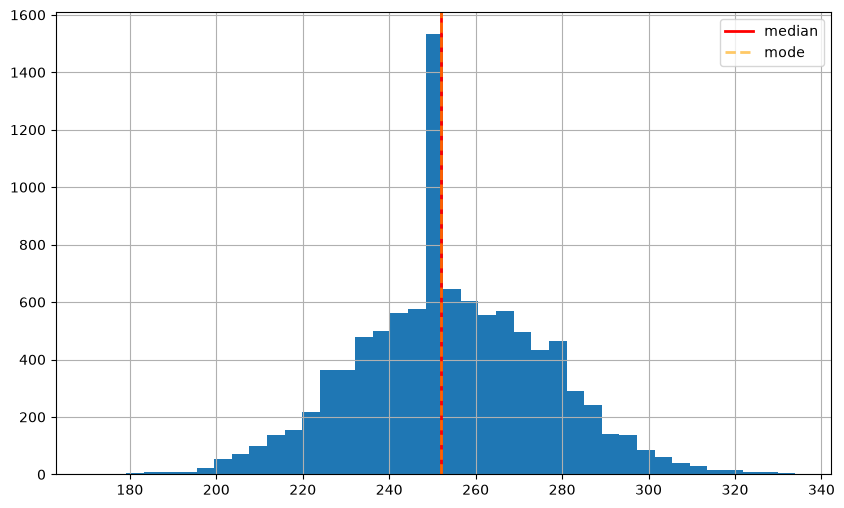

In [94]:
plt.figure(figsize=(10, 6))

df_car["horsepower_filled"].hist(bins=40)

plt.axvline(horsepower_filled_median, color='red', linestyle='-', linewidth=2, label=f'median')
plt.axvline(horsepower_filled_mode, color='orange', linestyle='--', alpha=0.6, linewidth=2, label=f'mode')

plt.legend()
plt.show()

> **Answer: Yes, the median decreased.**

## **Question 07**

- **Problem statement: What's the sum of all the elements of `w = (XᵀX)⁻¹ Xᵀ y`, using the first 7 cars from Asia (`vehicle_weight` and `model_year`)?**

### **Solution**

In [ ]:
X = (
    df_car
    .loc[df_car["origin"] == "Asia", ["vehicle_weight", "model_year"]]
    .head(7)
    .to_numpy()
)

X

In [ ]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)

y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])

w = XTX_inv.dot(X.T).dot(y)
w

In [ ]:
w.sum()

> **Answer: The sum of the elements of `w` is approximately 0.369.**